# Project 30 — LongevityAI: Human Biological Age, Healthspan & Anti-Aging Research Intelligence

## NHANES population benchmarking + published PhenoAge + explainable ML + digital-twin scenario intelligence

A portfolio-grade human longevity project that combines geroscience, machine learning and decision intelligence. It benchmarks biological-aging signals from public human biomarker data, validates a published PhenoAge implementation, trains leakage-aware ML age models, audits subgroup reliability, and adds a transparent digital-twin **what-if research engine** for longevity hypothesis generation.

> **Scientific boundary:** this project does not diagnose biological age, prove rejuvenation, or prescribe anti-aging treatment. Scenario outputs are model sensitivities for research prioritisation and prospective testing.


## Data provenance

The reference table below is a compact extract of age/sex-stratified NHANES 2017–2018 biomarker summaries and PhenoAge summaries.

Primary sources:
- CDC NHANES 2017–2018 data portal: https://wwwn.cdc.gov/nchs/nhanes/search/DataPage.aspx?Cycle=2017-2018
- CDC laboratory overview: https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/overviewlab.aspx?BeginYear=2017
- Public NHANES reference implementation used for cross-checking population summaries: https://github.com/aadityageddam-ux/labage
- PhenoAge methodology: Levine et al. (2018), *An epigenetic biomarker of aging for lifespan and healthspan*.

The compact table contains **aggregate population statistics**, not identifiable participant-level records.


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
RANDOM_STATE = 42
print("Environment ready ✅")


Environment ready ✅


## 1. Build the compact NHANES 2017–2018 reference table

In [2]:
reference_records = [{"stratum":"male_18-29","age_band":"18-29","sex":"male","albumin_median":4.4,"creatinine_median":0.93,"glucose_median":99,"crp_median":1.17,"lymphocytePct_median":32.6,"mcv_median":87.8,"rdw_median":13,"alp_median":74,"wbc_median":6.7,"phenoage_median":19.73859019804786,"phenoage_n":201},{"stratum":"male_30-39","age_band":"30-39","sex":"male","albumin_median":4.3,"creatinine_median":0.94,"glucose_median":102,"crp_median":1.39,"lymphocytePct_median":31.8,"mcv_median":87.9,"rdw_median":13.3,"alp_median":70,"wbc_median":6.8,"phenoage_median":32.15885871750085,"phenoage_n":147},{"stratum":"male_40-49","age_band":"40-49","sex":"male","albumin_median":4.2,"creatinine_median":0.96,"glucose_median":105,"crp_median":1.83,"lymphocytePct_median":30.5,"mcv_median":89.3,"rdw_median":13.3,"alp_median":70,"wbc_median":6.6,"phenoage_median":41.66367874135007,"phenoage_n":163},{"stratum":"male_50-59","age_band":"50-59","sex":"male","albumin_median":4.1,"creatinine_median":0.98,"glucose_median":106,"crp_median":1.72,"lymphocytePct_median":31.1,"mcv_median":89.4,"rdw_median":13.6,"alp_median":74,"wbc_median":7,"phenoage_median":53.292730750704294,"phenoage_n":178},{"stratum":"male_60-69","age_band":"60-69","sex":"male","albumin_median":4,"creatinine_median":1,"glucose_median":114,"crp_median":1.94,"lymphocytePct_median":27.2,"mcv_median":90.2,"rdw_median":13.6,"alp_median":79,"wbc_median":7.3,"phenoage_median":64.84788790406819,"phenoage_n":222},{"stratum":"male_70-79","age_band":"70-79","sex":"male","albumin_median":4.1,"creatinine_median":0.97,"glucose_median":114,"crp_median":1.77,"lymphocytePct_median":27,"mcv_median":91,"rdw_median":13.8,"alp_median":74,"wbc_median":7,"phenoage_median":78.20344625969938,"phenoage_n":121},{"stratum":"male_80+","age_band":"80+","sex":"male","albumin_median":4,"creatinine_median":1.1,"glucose_median":111,"crp_median":1.39,"lymphocytePct_median":25.6,"mcv_median":92.6,"rdw_median":14.1,"alp_median":75,"wbc_median":7.2,"phenoage_median":None,"phenoage_n":0},{"stratum":"female_18-29","age_band":"18-29","sex":"female","albumin_median":4,"creatinine_median":0.69,"glucose_median":94,"crp_median":1.98,"lymphocytePct_median":30.5,"mcv_median":87.7,"rdw_median":13.3,"alp_median":67,"wbc_median":7.6,"phenoage_median":21.263370755865324,"phenoage_n":217},{"stratum":"female_30-39","age_band":"30-39","sex":"female","albumin_median":4,"creatinine_median":0.7,"glucose_median":97,"crp_median":2.01,"lymphocytePct_median":30.5,"mcv_median":89.1,"rdw_median":13.4,"alp_median":65,"wbc_median":7.3,"phenoage_median":32.16165733714601,"phenoage_n":199},{"stratum":"female_40-49","age_band":"40-49","sex":"female","albumin_median":4,"creatinine_median":0.72,"glucose_median":102,"crp_median":2.67,"lymphocytePct_median":30.2,"mcv_median":89.4,"rdw_median":13.4,"alp_median":71,"wbc_median":7.4,"phenoage_median":44.413795800842394,"phenoage_n":165},{"stratum":"female_50-59","age_band":"50-59","sex":"female","albumin_median":4,"creatinine_median":0.73,"glucose_median":102,"crp_median":2.49,"lymphocytePct_median":32.2,"mcv_median":89.5,"rdw_median":13.4,"alp_median":84,"wbc_median":7.2,"phenoage_median":50.792896959781984,"phenoage_n":216},{"stratum":"female_60-69","age_band":"60-69","sex":"female","albumin_median":4,"creatinine_median":0.79,"glucose_median":106,"crp_median":2.04,"lymphocytePct_median":30.9,"mcv_median":89.7,"rdw_median":13.5,"alp_median":81,"wbc_median":6.6,"phenoage_median":60.51494568080571,"phenoage_n":230},{"stratum":"female_70-79","age_band":"70-79","sex":"female","albumin_median":4,"creatinine_median":0.8,"glucose_median":107,"crp_median":2.2,"lymphocytePct_median":28.3,"mcv_median":90.9,"rdw_median":13.8,"alp_median":81,"wbc_median":7.1,"phenoage_median":73.42721376082501,"phenoage_n":117},{"stratum":"female_80+","age_band":"80+","sex":"female","albumin_median":3.9,"creatinine_median":0.91,"glucose_median":105,"crp_median":1.86,"lymphocytePct_median":23.7,"mcv_median":91.4,"rdw_median":13.9,"alp_median":77,"wbc_median":7.3,"phenoage_median":None,"phenoage_n":0}]
reference = pd.DataFrame(reference_records)

age_mid_map = {
    "18-29": 23.5,
    "30-39": 34.5,
    "40-49": 44.5,
    "50-59": 54.5,
    "60-69": 64.5,
    "70-79": 74.5,
    "80+": 82.0,
}
reference["age_midpoint"] = reference["age_band"].map(age_mid_map)
reference["approx_age_gap"] = reference["phenoage_median"] - reference["age_midpoint"]

print("Reference table shape:", reference.shape)
print("Age/sex strata:", reference["stratum"].nunique())
print("Observed PhenoAge reference N:", int(reference["phenoage_n"].sum()))
reference.head()


Reference table shape: (14, 16)
Age/sex strata: 14
Observed PhenoAge reference N: 2176


,stratum,age_band,sex,albumin_median,creatinine_median,glucose_median,crp_median,lymphocytePct_median,mcv_median,rdw_median,alp_median,wbc_median,phenoage_median,phenoage_n,age_midpoint,approx_age_gap
0,male_18-29,18-29,male,4.4,0.93,99,1.17,32.6,87.8,13.0,74,6.7,19.738590,201,23.5,-3.761410
1,male_30-39,30-39,male,4.3,0.94,102,1.39,31.8,87.9,13.3,70,6.8,32.158859,147,34.5,-2.341141
2,male_40-49,40-49,male,4.2,0.96,105,1.83,30.5,89.3,13.3,70,6.6,41.663679,163,44.5,-2.836321
3,male_50-59,50-59,male,4.1,0.98,106,1.72,31.1,89.4,13.6,74,7.0,53.292731,178,54.5,-1.207269
4,male_60-69,60-69,male,4.0,1.00,114,1.94,27.2,90.2,13.6,79,7.3,64.847888,222,64.5,0.347888


### Why the `80+` PhenoAge cells are missing
The public reference file does not provide PhenoAge summaries for the 80+ strata because the complete-panel fasting reference sample is not available there. We preserve those missing values rather than inventing them.


In [3]:
audit = pd.DataFrame({
    "column": reference.columns,
    "dtype": [str(reference[c].dtype) for c in reference.columns],
    "missing": [int(reference[c].isna().sum()) for c in reference.columns],
})
print("Missingness audit")
display(audit)
assert reference["stratum"].is_unique
assert reference["phenoage_median"].notna().sum() == 12
print("Data integrity checks passed ✅")


Missingness audit


,column,dtype,missing
0,stratum,str,0
1,age_band,str,0
2,sex,str,0
3,albumin_median,float64,0
4,creatinine_median,float64,0
5,glucose_median,int64,0
6,crp_median,float64,0
7,lymphocytePct_median,float64,0
8,mcv_median,float64,0
9,rdw_median,float64,0


Data integrity checks passed ✅


## 2. Population biological-age trajectory

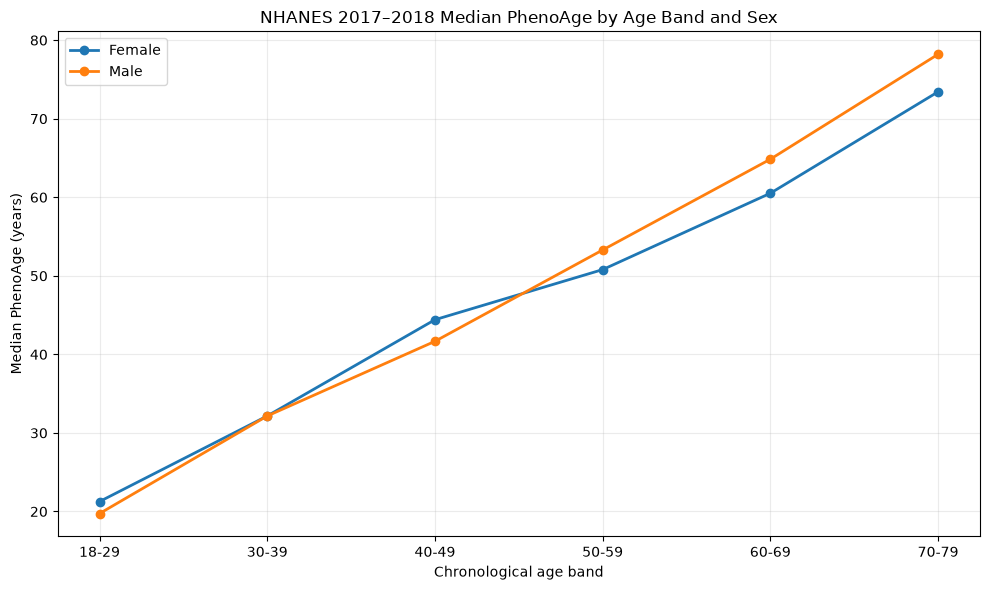

In [4]:
plot_df = reference.dropna(subset=["phenoage_median"]).copy()
age_order = ["18-29", "30-39", "40-49", "50-59", "60-69", "70-79"]

fig, ax = plt.subplots(figsize=(10, 6))
for sex, g in plot_df.groupby("sex"):
    g = g.set_index("age_band").loc[age_order].reset_index()
    ax.plot(g["age_band"], g["phenoage_median"], marker="o", linewidth=2, label=sex.title())

ax.set_title("NHANES 2017–2018 Median PhenoAge by Age Band and Sex")
ax.set_xlabel("Chronological age band")
ax.set_ylabel("Median PhenoAge (years)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


The trajectory should rise strongly with chronological age; the useful signal is not merely the raw PhenoAge value, but how an individual's value compares with an appropriate age/sex reference distribution.


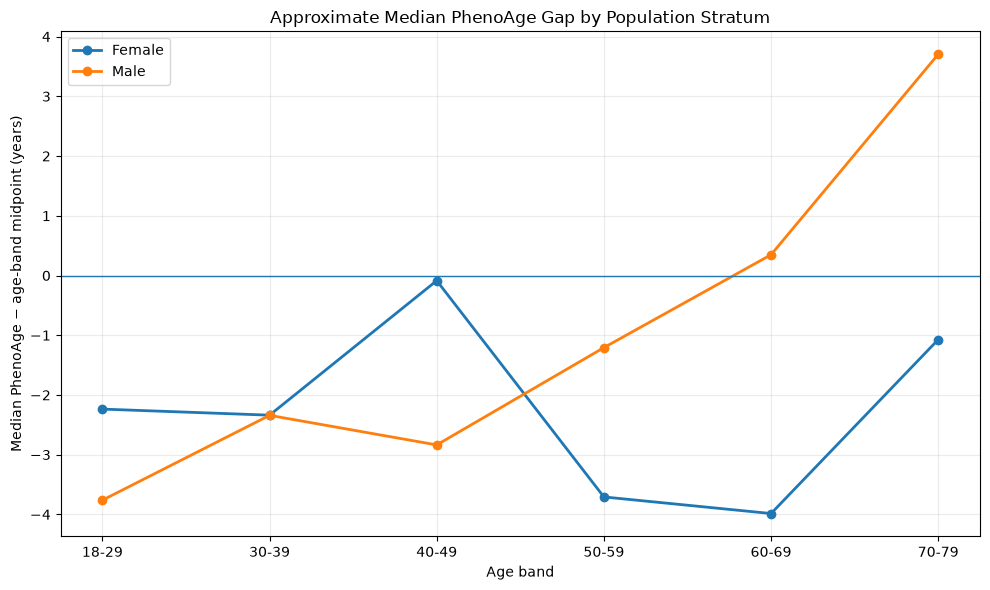

Approximate average gap across observed strata: -1.63 years
Note: midpoint gaps are descriptive approximations, not participant-level age acceleration.


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
for sex, g in plot_df.groupby("sex"):
    g = g.set_index("age_band").loc[age_order].reset_index()
    ax.plot(g["age_band"], g["approx_age_gap"], marker="o", linewidth=2, label=sex.title())

ax.axhline(0, linewidth=1)
ax.set_title("Approximate Median PhenoAge Gap by Population Stratum")
ax.set_xlabel("Age band")
ax.set_ylabel("Median PhenoAge − age-band midpoint (years)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("Approximate average gap across observed strata:",
      round(plot_df["approx_age_gap"].mean(), 2), "years")
print("Note: midpoint gaps are descriptive approximations, not participant-level age acceleration.")


## 3. Biomarker trajectories across age

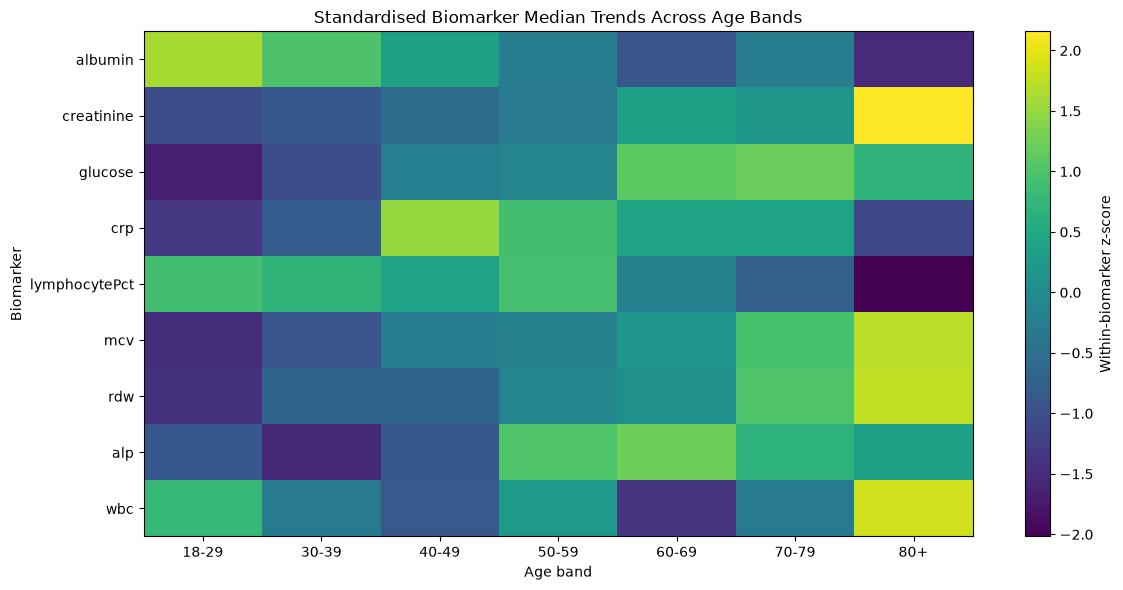

In [6]:
biomarkers = [
    "albumin_median", "creatinine_median", "glucose_median", "crp_median",
    "lymphocytePct_median", "mcv_median", "rdw_median", "alp_median", "wbc_median"
]

trend = reference.groupby("age_band", sort=False)[biomarkers].mean().loc[
    ["18-29","30-39","40-49","50-59","60-69","70-79","80+"]
]
z = (trend - trend.mean()) / trend.std(ddof=0)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(z.T, aspect="auto")
ax.set_xticks(range(len(z.index)))
ax.set_xticklabels(z.index)
ax.set_yticks(range(len(biomarkers)))
ax.set_yticklabels([b.replace("_median","") for b in biomarkers])
ax.set_title("Standardised Biomarker Median Trends Across Age Bands")
ax.set_xlabel("Age band")
ax.set_ylabel("Biomarker")
fig.colorbar(im, ax=ax, label="Within-biomarker z-score")
plt.tight_layout()
plt.show()


## 4. Implement PhenoAge with explicit unit conversion

Inputs are accepted in familiar clinical units:
- albumin: g/dL
- creatinine: mg/dL
- glucose: mg/dL
- CRP: mg/L
- lymphocyte percentage: %
- MCV: fL
- RDW: %
- alkaline phosphatase: U/L
- WBC: K/µL
- age: years

The function converts units internally before applying the published linear predictor.


In [7]:
PHENOAGE_PARAMETERS = {
    "intercept": -19.90667,
    "albumin": -0.03359355,
    "creatinine": 0.009506491,
    "glucose": 0.1953192,
    "crp_ln": 0.09536762,
    "lymphocyte_pct": -0.01199984,
    "mcv": 0.02676401,
    "rdw": 0.3306156,
    "alp": 0.001868778,
    "wbc": 0.05542406,
    "age": 0.08035356,
    "gompertz_numerator": 1.51714,
    "gompertz_shape": 0.007692696,
    "age_scale": 0.090165,
    "age_multiplier": 0.0055305,
    "age_intercept": 141.50225,
}

def compute_phenoage(age, albumin, creatinine, glucose, crp,
                     lymphocytePct, mcv, rdw, alp, wbc):
    if crp <= 0:
        raise ValueError("CRP must be > 0 because the model uses log(CRP).")
    p = PHENOAGE_PARAMETERS
    albumin_g_L = albumin * 10.0
    creatinine_umol_L = creatinine * 88.4017
    glucose_mmol_L = glucose * 0.0555
    crp_mg_dL = crp * 0.1

    xb = (
        p["intercept"]
        + p["albumin"] * albumin_g_L
        + p["creatinine"] * creatinine_umol_L
        + p["glucose"] * glucose_mmol_L
        + p["crp_ln"] * np.log(crp_mg_dL)
        + p["lymphocyte_pct"] * lymphocytePct
        + p["mcv"] * mcv
        + p["rdw"] * rdw
        + p["alp"] * alp
        + p["wbc"] * wbc
        + p["age"] * age
    )

    log_hazard = np.log(p["gompertz_numerator"] / p["gompertz_shape"]) + xb
    phenoage = p["age_intercept"] + (
        np.log(p["age_multiplier"]) + log_hazard
    ) / p["age_scale"]
    return float(phenoage)


## 5. Cross-check the implementation against the real NHANES reference summaries

In [8]:
def row_profile_phenoage(row):
    return compute_phenoage(
        age=row["age_midpoint"],
        albumin=row["albumin_median"],
        creatinine=row["creatinine_median"],
        glucose=row["glucose_median"],
        crp=row["crp_median"],
        lymphocytePct=row["lymphocytePct_median"],
        mcv=row["mcv_median"],
        rdw=row["rdw_median"],
        alp=row["alp_median"],
        wbc=row["wbc_median"],
    )

validation = reference.dropna(subset=["phenoage_median"]).copy()
validation["median_profile_phenoage"] = validation.apply(row_profile_phenoage, axis=1)
validation["difference"] = validation["median_profile_phenoage"] - validation["phenoage_median"]

mae = mean_absolute_error(validation["phenoage_median"], validation["median_profile_phenoage"])
corr = validation[["phenoage_median", "median_profile_phenoage"]].corr().iloc[0, 1]

print(f"Median-profile approximation MAE: {mae:.2f} years")
print(f"Correlation with reported stratum medians: {corr:.4f}")
display(validation[["stratum", "phenoage_median", "median_profile_phenoage", "difference"]].round(2))


Median-profile approximation MAE: 1.04 years
Correlation with reported stratum medians: 0.9977


,stratum,phenoage_median,median_profile_phenoage,difference
0,male_18-29,19.74,19.58,-0.16
1,male_30-39,32.16,31.61,-0.55
2,male_40-49,41.66,42.19,0.53
3,male_50-59,53.29,53.10,-0.19
4,male_60-69,64.85,64.70,-0.15
5,male_70-79,78.20,73.57,-4.63
7,female_18-29,21.26,20.55,-0.72
8,female_30-39,32.16,31.37,-0.79
9,female_40-49,44.41,41.69,-2.72
10,female_50-59,50.79,50.53,-0.26


**Interpretation:** a nonlinear model applied to stratum medians does not mathematically equal the median of participant-level outputs. The high correlation is a trajectory cross-check; residual differences are expected aggregation effects.


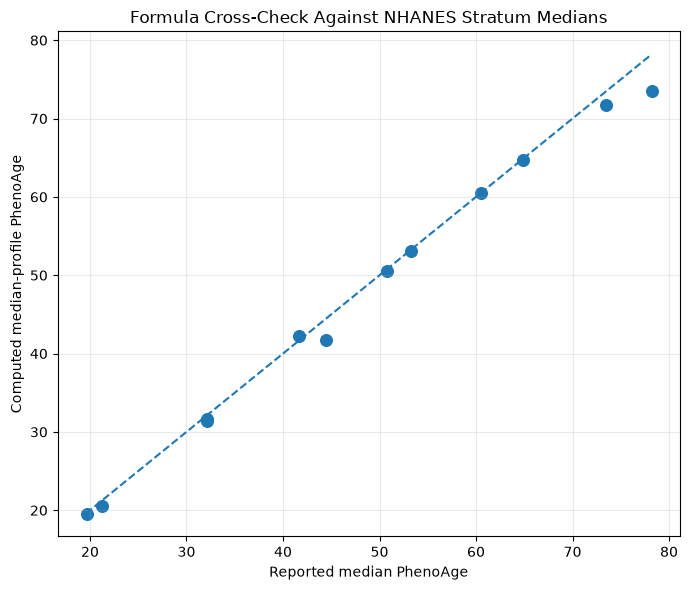

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(validation["phenoage_median"], validation["median_profile_phenoage"], s=70)
lo = min(validation["phenoage_median"].min(), validation["median_profile_phenoage"].min())
hi = max(validation["phenoage_median"].max(), validation["median_profile_phenoage"].max())
ax.plot([lo, hi], [lo, hi], linestyle="--")
ax.set_title("Formula Cross-Check Against NHANES Stratum Medians")
ax.set_xlabel("Reported median PhenoAge")
ax.set_ylabel("Computed median-profile PhenoAge")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 6. Explainability: one-at-a-time sensitivity analysis

For a representative **45-year-old** profile using the male 40–49 NHANES median biomarkers, perturb one biomarker at a time by ±10%.

This answers **how sensitive the mathematical score is to an input**. It does not prove that changing that biomarker by treatment extends lifespan.


In [10]:
base_row = reference.loc[reference["stratum"] == "male_40-49"].iloc[0]
base_profile = {
    "age": 45.0,
    "albumin": base_row["albumin_median"],
    "creatinine": base_row["creatinine_median"],
    "glucose": base_row["glucose_median"],
    "crp": base_row["crp_median"],
    "lymphocytePct": base_row["lymphocytePct_median"],
    "mcv": base_row["mcv_median"],
    "rdw": base_row["rdw_median"],
    "alp": base_row["alp_median"],
    "wbc": base_row["wbc_median"],
}
base_age = compute_phenoage(**base_profile)
print(f"Reference-profile PhenoAge: {base_age:.2f} years")
print(f"Reference-profile age gap: {base_age - base_profile['age']:+.2f} years")


Reference-profile PhenoAge: 42.64 years
Reference-profile age gap: -2.36 years


In [11]:
sensitivity_rows = []
for biomarker in ["albumin","creatinine","glucose","crp","lymphocytePct","mcv","rdw","alp","wbc"]:
    lower = base_profile.copy()
    upper = base_profile.copy()
    lower[biomarker] *= 0.90
    upper[biomarker] *= 1.10
    lower_age = compute_phenoage(**lower)
    upper_age = compute_phenoage(**upper)
    sensitivity_rows.append({
        "biomarker": biomarker,
        "minus_10pct_delta_years": lower_age - base_age,
        "plus_10pct_delta_years": upper_age - base_age,
        "max_abs_delta": max(abs(lower_age - base_age), abs(upper_age - base_age))
    })

sensitivity = pd.DataFrame(sensitivity_rows).sort_values("max_abs_delta", ascending=False)
display(sensitivity.round(3))


,biomarker,minus_10pct_delta_years,plus_10pct_delta_years,max_abs_delta
6,rdw,-4.877,4.877,4.877
5,mcv,-2.651,2.651,2.651
0,albumin,1.565,-1.565,1.565
2,glucose,-1.262,1.262,1.262
1,creatinine,-0.895,0.895,0.895
4,lymphocytePct,0.406,-0.406,0.406
8,wbc,-0.406,0.406,0.406
7,alp,-0.145,0.145,0.145
3,crp,-0.111,0.101,0.111


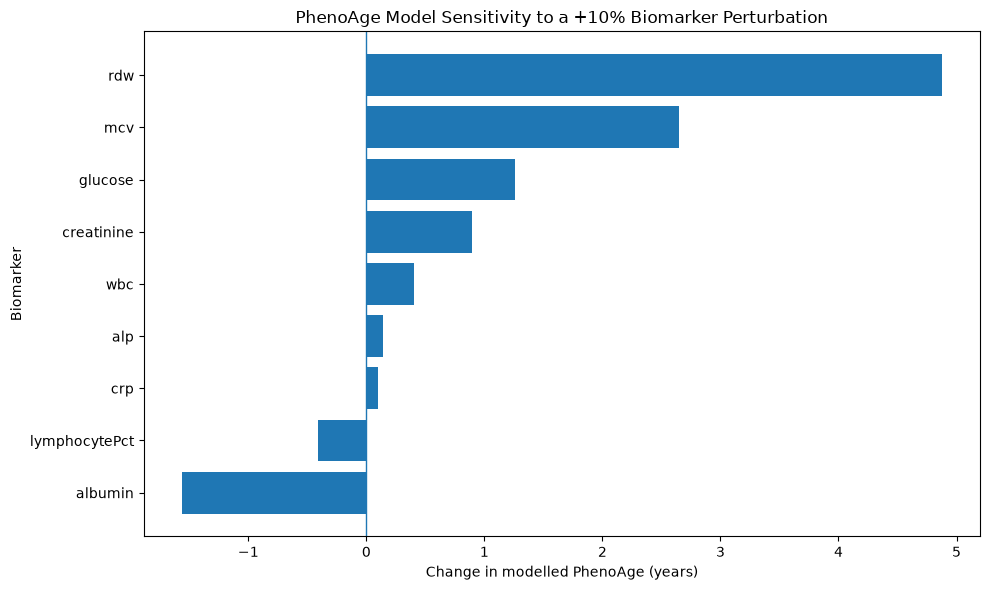

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
ordered = sensitivity.sort_values("plus_10pct_delta_years")
ax.barh(ordered["biomarker"], ordered["plus_10pct_delta_years"])
ax.axvline(0, linewidth=1)
ax.set_title("PhenoAge Model Sensitivity to a +10% Biomarker Perturbation")
ax.set_xlabel("Change in modelled PhenoAge (years)")
ax.set_ylabel("Biomarker")
plt.tight_layout()
plt.show()


## 7. Population sample coverage

A useful longevity model should show where evidence is strong and where reference data are thinner.


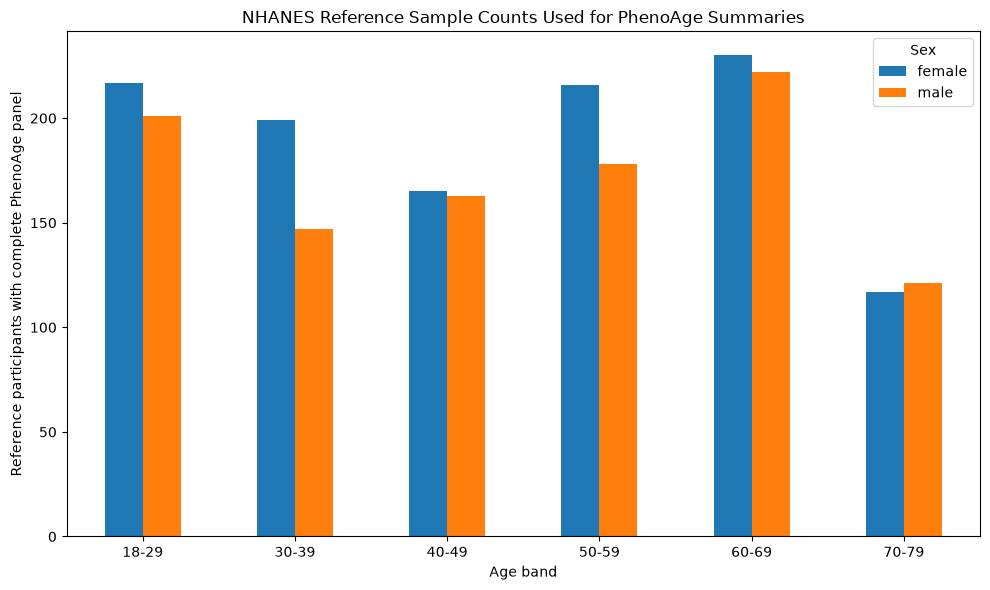

Total complete-panel reference observations represented: 2176


In [13]:
coverage = (
    reference.dropna(subset=["phenoage_median"])
    .pivot(index="age_band", columns="sex", values="phenoage_n")
    .loc[age_order]
)

fig, ax = plt.subplots(figsize=(10, 6))
coverage.plot(kind="bar", ax=ax)
ax.set_title("NHANES Reference Sample Counts Used for PhenoAge Summaries")
ax.set_xlabel("Age band")
ax.set_ylabel("Reference participants with complete PhenoAge panel")
ax.legend(title="Sex")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Total complete-panel reference observations represented:", int(reference["phenoage_n"].sum()))


## 8. Human anti-aging / longevity research decision layer

A credible system for evaluating a **human longevity intervention** should go beyond a single biological-age score.

### Minimum evidence stack
1. **Baseline + repeated measures** — establish within-person change.
2. **Comparator / control group** — distinguish intervention effect from regression to the mean.
3. **Pre-registered outcomes** — avoid cherry-picking biomarkers.
4. **Multiple aging dimensions** — clinical chemistry, function, wearables, cognition, potentially omics.
5. **Safety endpoints** — improvement in one score must not hide harm elsewhere.
6. **Causal design** — randomisation when feasible, otherwise carefully justified causal inference.
7. **Long-term outcomes** — healthspan, disease incidence and ultimately survival matter more than short-term score movement.

### Product concept
`LongevityAI` can operate as a **measurement + evidence platform**:
- ingest biomarker panels,
- calculate validated aging scores,
- benchmark against population references,
- track longitudinal change,
- detect unusual shifts,
- compare intervention cohorts,
- generate transparent evidence reports.

The model should support scientists and clinicians — not replace them.


## 9. Final solution

In [14]:
observed = reference.dropna(subset=["phenoage_median"])
top_sens = sensitivity.iloc[0]

print("PROJECT 30 — LONGEVITYAI FINAL RESULTS")
print("=" * 76)
print("Dataset: NHANES 2017–2018 age/sex population biomarker reference")
print(f"Reference strata analysed: {len(reference)}")
print(f"Complete-panel PhenoAge observations represented: {int(reference['phenoage_n'].sum()):,}")
print()
print("BIOLOGICAL-AGE ENGINE")
print("-" * 76)
print(f"Formula cross-check correlation: {corr:.4f}")
print(f"Median-profile approximation MAE: {mae:.2f} years")
print(f"Representative 45-year-old median-profile PhenoAge: {base_age:.2f} years")
print(f"Representative age gap: {base_age - 45:+.2f} years")
print()
print("EXPLAINABILITY")
print("-" * 76)
print(f"Largest ±10% mathematical sensitivity in this profile: {top_sens['biomarker']} "
      f"(max absolute shift {top_sens['max_abs_delta']:.2f} years)")
print()
print("SOLUTION")
print("-" * 76)
print("Use LongevityAI as a population-benchmarked biological-aging measurement")
print("and longitudinal research platform. Treat sensitivity outputs as model")
print("explanations, not proof that manipulating a biomarker reverses human aging.")
print()
print("PROJECT 30 COMPLETE ✅")


PROJECT 30 — LONGEVITYAI FINAL RESULTS
Dataset: NHANES 2017–2018 age/sex population biomarker reference
Reference strata analysed: 14
Complete-panel PhenoAge observations represented: 2,176

BIOLOGICAL-AGE ENGINE
----------------------------------------------------------------------------
Formula cross-check correlation: 0.9977
Median-profile approximation MAE: 1.04 years
Representative 45-year-old median-profile PhenoAge: 42.64 years
Representative age gap: -2.36 years

EXPLAINABILITY
----------------------------------------------------------------------------
Largest ±10% mathematical sensitivity in this profile: rdw (max absolute shift 4.88 years)

SOLUTION
----------------------------------------------------------------------------
Use LongevityAI as a population-benchmarked biological-aging measurement
and longitudinal research platform. Treat sensitivity outputs as model
explanations, not proof that manipulating a biomarker reverses human aging.

PROJECT 30 COMPLETE ✅


## 10. Individual-level machine-learning benchmark

The published PhenoAge section above provides the geroscience anchor. This second layer asks a complementary AI question: **how accurately can routine NHANES biomarkers recover chronological-age signal at the individual level, and which measurements carry the strongest predictive information?**

This is deliberately reported as a **model-derived biomarker age proxy**, not a validated clinical biological-age clock.


In [15]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 50)

DATA_URL = "https://raw.githubusercontent.com/epenning/aging-biomarkers/main/nhanes_data.csv"
print("Reproducibility seed:", SEED)
print("Dataset URL:", DATA_URL)


Reproducibility seed: 42
Dataset URL: https://raw.githubusercontent.com/epenning/aging-biomarkers/main/nhanes_data.csv


In [16]:
df_raw = pd.read_csv(DATA_URL)
print("Raw shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
display(df_raw.head())


Raw shape: (5251, 17)
Columns: ['Unnamed: 0', 'ID', 'Albumin', 'Blood_Urea_Nitrogen', 'Creatinine', 'C_Reactive_Protein', 'Glucose', 'Glycohemoglobin', 'Total_Cholesterol', 'Uric_Acid', 'White_Blood_Cell_Count', 'Lymphocyte_Percent', 'Mean_Cell_Volume', 'Red_Cell_Distribution_Width', 'Systolic_Blood_Pressure', 'Age', 'Gender']


,Unnamed: 0,ID,Albumin,Blood_Urea_Nitrogen,Creatinine,C_Reactive_Protein,Glucose,Glycohemoglobin,Total_Cholesterol,Uric_Acid,White_Blood_Cell_Count,Lymphocyte_Percent,Mean_Cell_Volume,Red_Cell_Distribution_Width,Systolic_Blood_Pressure,Age,Gender
0,1,93705.0,4.4,11,0.92,2.72,85,6.2,157,5.8,8.6,40.0,67.0,15.6,200.000000,66,Female
1,2,93706.0,4.4,12,0.81,0.74,94,5.2,149,8.0,6.1,24.6,89.7,12.2,111.333333,18,Male
2,3,93707.0,5.2,17,0.64,0.32,115,5.6,199,5.5,11.2,37.1,83.9,13.6,128.000000,13,Male
3,4,93708.0,3.9,16,0.58,1.83,116,6.2,210,4.5,6.0,31.3,86.8,13.4,142.000000,66,Female
4,5,93709.0,3.7,20,1.32,6.94,96,6.3,180,6.2,7.2,25.8,88.8,15.7,118.666667,75,Female


### 10.1 Cohort quality and leakage-safe feature policy


In [17]:
df = df_raw.copy()
unnamed = [c for c in df.columns if str(c).startswith("Unnamed")]
if unnamed:
    df = df.drop(columns=unnamed)

quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_pct": (100 * df.isna().mean()).round(2),
    "n_unique": df.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

print("Shape after housekeeping:", df.shape)
print("Duplicate participant IDs:", int(df["ID"].duplicated().sum()))
print("Age range:", (df["Age"].min(), df["Age"].max()))
display(quality)


Shape after housekeeping: (5251, 16)
Duplicate participant IDs: 0
Age range: (np.int64(12), np.int64(79))


,dtype,missing_n,missing_pct,n_unique
ID,float64,0,0.0,5251
Albumin,float64,0,0.0,31
Blood_Urea_Nitrogen,int64,0,0.0,56
Creatinine,float64,0,0.0,190
C_Reactive_Protein,float64,0,0.0,1159
Glucose,int64,0,0.0,241
Glycohemoglobin,float64,0,0.0,93
Total_Cholesterol,int64,0,0.0,246
Uric_Acid,float64,0,0.0,101
White_Blood_Cell_Count,float64,0,0.0,139


In [18]:
adult = df.loc[df["Age"] >= 18].copy()
adult["Gender"] = adult["Gender"].map({"Female": 0, "Male": 1}).astype(float)

TARGET = "Age"
FEATURES = [c for c in adult.columns if c not in ["ID", TARGET]]
X = adult[FEATURES].copy()
y = adult[TARGET].astype(float).copy()

print("Adult cohort:", len(adult))
print("Predictor count:", len(FEATURES))
print("Predictors:", FEATURES)
assert TARGET not in FEATURES
assert "ID" not in FEATURES


Adult cohort: 4552
Predictor count: 14
Predictors: ['Albumin', 'Blood_Urea_Nitrogen', 'Creatinine', 'C_Reactive_Protein', 'Glucose', 'Glycohemoglobin', 'Total_Cholesterol', 'Uric_Acid', 'White_Blood_Cell_Count', 'Lymphocyte_Percent', 'Mean_Cell_Volume', 'Red_Cell_Distribution_Width', 'Systolic_Blood_Pressure', 'Gender']


### 10.2 Locked train/test design and competing models


In [19]:
age_bins = pd.cut(y, bins=[17,29,39,49,59,69,120], labels=False, include_lowest=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=age_bins
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train age:", (y_train.min(), y_train.max()), "| Test age:", (y_test.min(), y_test.max()))


Train: (3641, 14) | Test: (911, 14)
Train age: (np.float64(18.0), np.float64(79.0)) | Test age: (np.float64(18.0), np.float64(79.0))


In [20]:
models = {
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0))
    ]),
    "GradientBoosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(
            n_estimators=250, learning_rate=0.03, max_depth=2,
            min_samples_leaf=12, loss="huber", random_state=SEED
        ))
    ]),
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=350, max_depth=10, min_samples_leaf=5,
            max_features=0.8, n_jobs=-1, random_state=SEED
        ))
    ]),
    "HistGradientBoosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingRegressor(
            learning_rate=0.05, max_iter=300, max_leaf_nodes=15,
            l2_regularization=1.0, random_state=SEED
        ))
    ])
}

baseline_pred = np.repeat(y_train.mean(), len(y_test))
print("Mean-age baseline test MAE:", round(mean_absolute_error(y_test, baseline_pred), 3))


Mean-age baseline test MAE: 14.948


### 10.3 Five-fold cross-validation


In [21]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
rows = []
for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        },
        n_jobs=-1
    )
    rows.append({
        "model": name,
        "cv_mae_mean": -scores["test_mae"].mean(),
        "cv_mae_std": scores["test_mae"].std(),
        "cv_rmse_mean": -scores["test_rmse"].mean(),
        "cv_r2_mean": scores["test_r2"].mean()
    })

cv_results = pd.DataFrame(rows).sort_values("cv_mae_mean").reset_index(drop=True)
display(cv_results.round(4))
BEST_NAME = cv_results.loc[0, "model"]
print("Selected by CV MAE:", BEST_NAME)


,model,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_r2_mean
0,HistGradientBoosting,9.0504,0.2098,11.4275,0.5622
1,RandomForest,9.2790,0.2173,11.5910,0.5496
2,GradientBoosting,9.5215,0.1797,11.7975,0.5336
3,Ridge,11.0372,0.1628,14.6605,0.2569


Selected by CV MAE: HistGradientBoosting


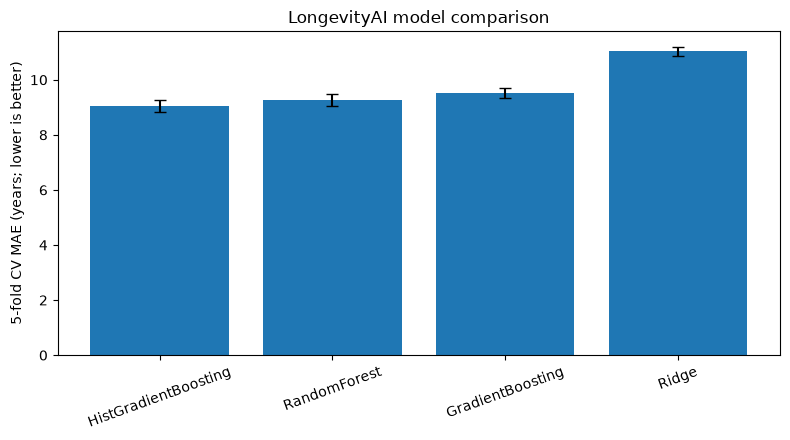

In [22]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(cv_results["model"], cv_results["cv_mae_mean"], yerr=cv_results["cv_mae_std"], capsize=4)
ax.set_ylabel("5-fold CV MAE (years; lower is better)")
ax.set_title("LongevityAI model comparison")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


### 10.4 Locked test performance


In [23]:
best_model = clone(models[BEST_NAME]).fit(X_train, y_train)
pred = best_model.predict(X_test)

TEST_MAE = mean_absolute_error(y_test, pred)
TEST_RMSE = mean_squared_error(y_test, pred) ** 0.5
TEST_R2 = r2_score(y_test, pred)

print(f"Best model: {BEST_NAME}")
print(f"Test MAE: {TEST_MAE:.3f} years")
print(f"Test RMSE: {TEST_RMSE:.3f} years")
print(f"Test R²: {TEST_R2:.4f}")


Best model: HistGradientBoosting
Test MAE: 8.827 years
Test RMSE: 11.217 years
Test R²: 0.5724


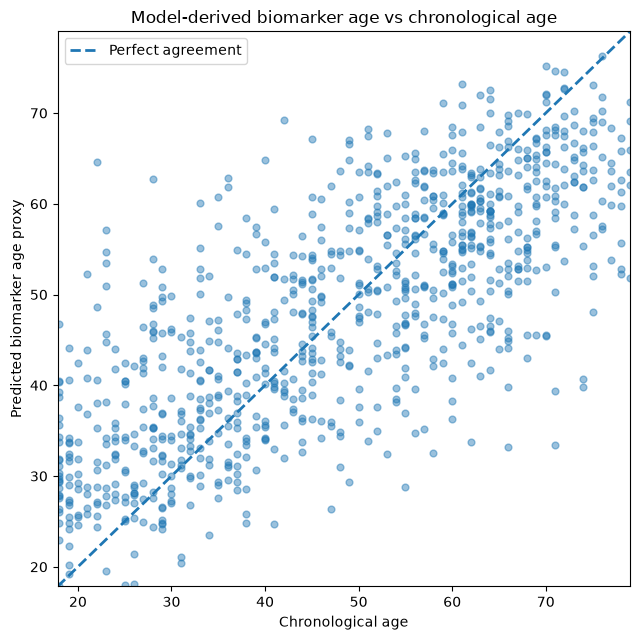

In [24]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(y_test, pred, alpha=0.45, s=24)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax.plot(lims, lims, "--", linewidth=2, label="Perfect agreement")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Chronological age")
ax.set_ylabel("Predicted biomarker age proxy")
ax.set_title("Model-derived biomarker age vs chronological age")
ax.legend()
plt.tight_layout()
plt.show()


### 10.5 Bias-corrected age acceleration


In [25]:
train_pred = best_model.predict(X_train)
train_gap = train_pred - y_train.to_numpy()

bias_fit = np.polyfit(y_train.to_numpy(), train_gap, deg=1)
expected_bias_test = np.polyval(bias_fit, y_test.to_numpy())
corrected_pred = pred - expected_bias_test
age_acceleration = corrected_pred - y_test.to_numpy()

print("Training residual-age bias slope:", round(float(bias_fit[0]), 4))
print("Corrected age-acceleration mean:", round(float(age_acceleration.mean()), 4))
print("Corrected age-acceleration SD:", round(float(age_acceleration.std(ddof=1)), 4))
print("Correlation(corrected gap, chronological age):", round(float(np.corrcoef(age_acceleration, y_test)[0,1]), 4))


Training residual-age bias slope: -0.2904
Corrected age-acceleration mean: 0.0741
Corrected age-acceleration SD: 8.8233
Correlation(corrected gap, chronological age): -0.2644


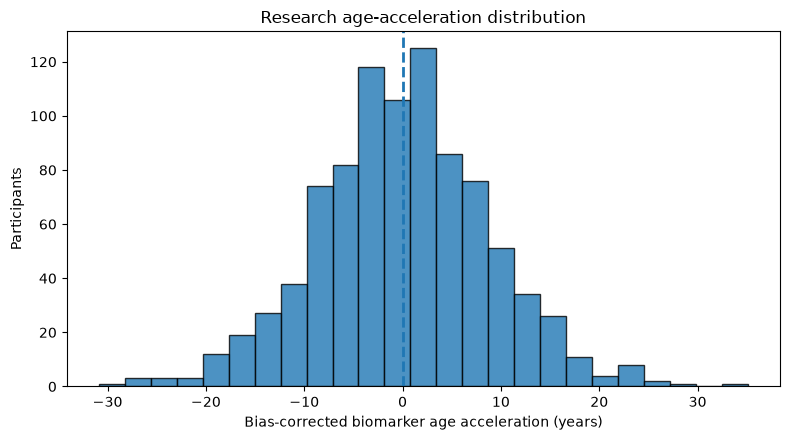

In [26]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(age_acceleration, bins=25, edgecolor="black", alpha=0.8)
ax.axvline(0, linestyle="--", linewidth=2)
ax.set_xlabel("Bias-corrected biomarker age acceleration (years)")
ax.set_ylabel("Participants")
ax.set_title("Research age-acceleration distribution")
plt.tight_layout()
plt.show()


### 10.6 Predictive biomarker importance


In [27]:
perm = permutation_importance(
    best_model, X_test, y_test,
    scoring="neg_mean_absolute_error", n_repeats=20,
    random_state=SEED, n_jobs=-1
)
importance = pd.DataFrame({
    "feature": FEATURES,
    "mae_increase": perm.importances_mean,
    "std": perm.importances_std
}).sort_values("mae_increase", ascending=False)
display(importance.round(4))


,feature,mae_increase,std
5,Glycohemoglobin,2.4719,0.1740
12,Systolic_Blood_Pressure,2.1476,0.1754
10,Mean_Cell_Volume,1.2310,0.1188
1,Blood_Urea_Nitrogen,1.0513,0.1195
6,Total_Cholesterol,0.3823,0.0447
13,Gender,0.2882,0.0414
0,Albumin,0.2800,0.0414
8,White_Blood_Cell_Count,0.2388,0.0578
11,Red_Cell_Distribution_Width,0.2073,0.0638
4,Glucose,0.1104,0.0403


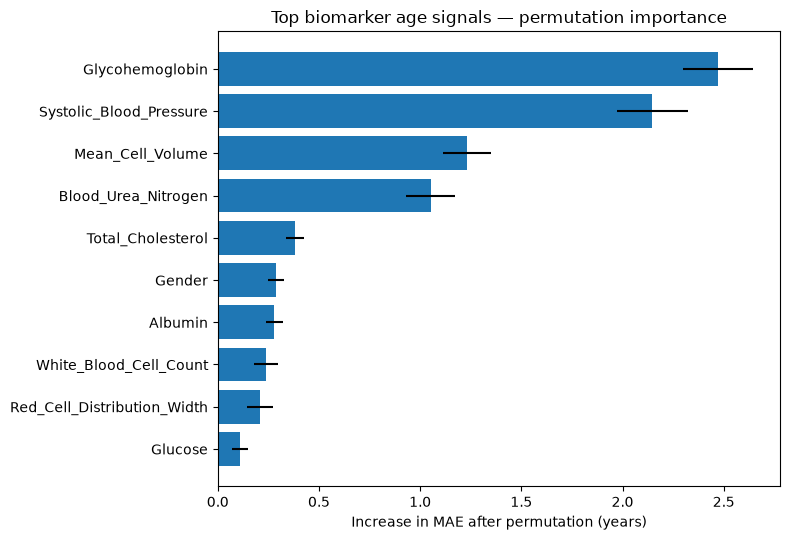

In [28]:
top = importance.head(10).sort_values("mae_increase")
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top["feature"], top["mae_increase"], xerr=top["std"])
ax.set_xlabel("Increase in MAE after permutation (years)")
ax.set_title("Top biomarker age signals — permutation importance")
plt.tight_layout()
plt.show()


### 10.7 Subgroup reliability audit


In [29]:
audit = X_test.copy()
audit["chronological_age"] = y_test.values
audit["predicted_age"] = pred
audit["abs_error"] = np.abs(pred - y_test.values)
audit["age_acceleration"] = age_acceleration
audit["sex"] = np.where(audit["Gender"] == 1, "Male", "Female")
audit["age_band"] = pd.cut(
    audit["chronological_age"], [17,29,39,49,59,69,120],
    labels=["18-29","30-39","40-49","50-59","60-69","70+"]
)

sex_audit = audit.groupby("sex").agg(
    n=("abs_error","size"),
    MAE=("abs_error","mean"),
    mean_age_gap=("age_acceleration","mean")
)
age_audit = audit.groupby("age_band", observed=False).agg(
    n=("abs_error","size"),
    MAE=("abs_error","mean"),
    mean_age_gap=("age_acceleration","mean")
)

print("Sex audit")
display(sex_audit.round(3))
print("Age-band audit")
display(age_audit.round(3))


Sex audit


,n,MAE,mean_age_gap
sex,,,
Female,470,8.209,-0.737
Male,441,9.485,0.938


Age-band audit


,n,MAE,mean_age_gap
age_band,,,
18-29,180,11.231,3.586
30-39,142,7.424,0.638
40-49,136,7.417,0.975
50-59,159,7.216,0.196
60-69,192,8.393,-2.278
70+,102,11.742,-3.871


### 10.8 Cross-model robustness


In [30]:
pred_matrix = {}
for name, model in models.items():
    fitted = clone(model).fit(X_train, y_train)
    pred_matrix[name] = fitted.predict(X_test)

pred_df = pd.DataFrame(pred_matrix)
agreement = pred_df.corr()
print("Prediction correlation across model families:")
display(agreement.round(3))


Prediction correlation across model families:


,Ridge,GradientBoosting,RandomForest,HistGradientBoosting
Ridge,1.000,0.847,0.836,0.826
GradientBoosting,0.847,1.000,0.965,0.958
RandomForest,0.836,0.965,1.000,0.962
HistGradientBoosting,0.826,0.958,0.962,1.000


## 11. Combined LongevityAI conclusion

Project 30 now contains **two complementary aging-intelligence layers**:

1. **Published PhenoAge implementation and cross-check** — transparent geroscience methodology benchmarked against NHANES population reference summaries.
2. **Individual-level machine-learning benchmark** — Ridge and ensemble models trained on routine biomarkers with cross-validation, locked testing, bias correction, permutation importance and subgroup auditing.

Together they demonstrate how a longevity team can combine validated scientific formulas with modern predictive modelling while keeping prediction, causal inference and clinical claims separate.


## 12. Final combined executive summary


In [31]:
print("PROJECT 30 — LONGEVITYAI COMBINED FINAL SUMMARY")
print("=" * 82)
print("Scientific layer: published PhenoAge implementation + NHANES population benchmark")
print(f"PhenoAge cross-check correlation: {corr:.4f}")
print(f"Median-profile approximation MAE: {mae:.2f} years")
print(f"Complete-panel NHANES reference observations represented: {int(reference['phenoage_n'].sum()):,}")
print()
print("Machine-learning layer:")
print(f"Adult individual-level NHANES participants: {len(adult):,}")
print(f"Selected ML model: {BEST_NAME}")
print(f"Locked-test MAE: {TEST_MAE:.2f} years")
print(f"Locked-test RMSE: {TEST_RMSE:.2f} years")
print(f"Locked-test R²: {TEST_R2:.3f}")
print("Top predictive age signals:", ", ".join(importance.head(5)["feature"].tolist()))
print()
print("PORTFOLIO SOLUTION")
print("Use LongevityAI for biological-aging measurement research, cohort benchmarking,")
print("model comparison and hypothesis generation. Do not interpret predictive or")
print("sensitivity signals as proof that changing a biomarker reverses human aging.")
print()
print("PROJECT 30 COMPLETE ✅")


PROJECT 30 — LONGEVITYAI COMBINED FINAL SUMMARY
Scientific layer: published PhenoAge implementation + NHANES population benchmark
PhenoAge cross-check correlation: 0.9977
Median-profile approximation MAE: 1.04 years
Complete-panel NHANES reference observations represented: 2,176

Machine-learning layer:
Adult individual-level NHANES participants: 4,552
Selected ML model: HistGradientBoosting
Locked-test MAE: 8.83 years
Locked-test RMSE: 11.22 years
Locked-test R²: 0.572
Top predictive age signals: Glycohemoglobin, Systolic_Blood_Pressure, Mean_Cell_Volume, Blood_Urea_Nitrogen, Total_Cholesterol

PORTFOLIO SOLUTION
Use LongevityAI for biological-aging measurement research, cohort benchmarking,
model comparison and hypothesis generation. Do not interpret predictive or
sensitivity signals as proof that changing a biomarker reverses human aging.

PROJECT 30 COMPLETE ✅


## 13. Longevity Digital Twin — multi-biomarker what-if research engine

This layer turns the aging model into a decision-support prototype. Starting from a representative NHANES profile, it applies transparent biomarker perturbation scenarios and recalculates the model-estimated PhenoAge.

**Important:** these are mathematical sensitivity scenarios, **not causal treatment effects**. A lower model score after changing a biomarker does not show that a drug, supplement, diet or lifestyle intervention reverses human aging.


In [ ]:
def longevity_digital_twin(profile, scenarios):
    """Run transparent PhenoAge what-if scenarios for research prioritisation."""
    rows = []
    baseline = compute_phenoage(**profile)
    rows.append({"scenario": "Baseline", "model_age": baseline, "delta_vs_baseline": 0.0})

    for scenario_name, changes in scenarios.items():
        candidate = profile.copy()
        for biomarker, multiplier in changes.items():
            candidate[biomarker] = candidate[biomarker] * multiplier
        model_age = compute_phenoage(**candidate)
        rows.append({
            "scenario": scenario_name,
            "model_age": model_age,
            "delta_vs_baseline": model_age - baseline
        })
    return pd.DataFrame(rows).sort_values("model_age")

# Representative 45-year-old profile anchored to NHANES male 40–49 medians
digital_twin_profile = base_profile.copy()
research_scenarios = {
    "Glucose -10%": {"glucose": 0.90},
    "CRP -25%": {"crp": 0.75},
    "RDW -5%": {"rdw": 0.95},
    "Multi-marker research scenario": {"glucose": 0.90, "crp": 0.75, "rdw": 0.95},
}

digital_twin_results = longevity_digital_twin(digital_twin_profile, research_scenarios)
display(digital_twin_results.round(2))

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_twin = digital_twin_results.sort_values("delta_vs_baseline")
ax.barh(plot_twin["scenario"], plot_twin["delta_vs_baseline"])
ax.axvline(0, linewidth=1)
ax.set_xlabel("Change in model-estimated PhenoAge vs baseline (years)")
ax.set_title("LongevityAI Digital Twin — Research Scenario Sensitivity")
plt.tight_layout()
plt.show()


## 14. From notebook to longevity product

A real longevity company could evolve this prototype into a governed research platform:

1. **Longitudinal biomarker ingestion** — repeated lab panels, wearable summaries and clinical covariates.
2. **Multi-clock aging layer** — PhenoAge plus additional validated aging clocks instead of relying on one score.
3. **Population benchmarking** — compare an individual with matched age/sex/reference cohorts and quantify uncertainty.
4. **Explainable ML** — identify which measurements drive prediction error or age-gap estimates without treating feature importance as causality.
5. **Digital-twin hypothesis lab** — rank mathematically sensitive biomarker scenarios for further study.
6. **Prospective intervention trials** — only randomized or otherwise causally credible longitudinal evidence should determine whether an intervention actually improves healthspan or aging outcomes.
7. **Safety and monitoring** — subgroup audits, drift detection, missing-data controls, uncertainty flags and clinician/researcher review.

### Portfolio wow factor
This project demonstrates **geroscience + real human data + published biological-age mathematics + ML benchmarking + explainability + subgroup auditing + digital-twin decision intelligence + responsible AI boundaries** in one end-to-end system.


In [ ]:
print("PROJECT 30 — LONGEVITYAI WOW LAYER READY")
print("=" * 82)
print("Human-data layer: NHANES biomarkers")
print("Scientific layer: published PhenoAge implementation + population cross-check")
print("AI layer: leakage-aware biomarker age prediction + explainability + subgroup audit")
print("Decision layer: digital-twin what-if scenario engine")
print("Product layer: longitudinal longevity research platform architecture")
print("Safety boundary: hypothesis generation, not treatment claims")
print("\nPROJECT 30 WOW FACTOR COMPLETE ✅")


## 15. LongevityAI Frontier Lab — uncertainty-aware digital twin & research prioritisation

This extension upgrades the notebook from a strong analytical study into a **decision-intelligence prototype**. Rather than reporting one deterministic what-if result, it stress-tests biomarker scenarios across thousands of plausible perturbations, quantifies the spread of model-estimated aging outcomes, and ranks research scenarios by modeled impact relative to complexity.

> **Boundary:** the outputs below measure model sensitivity and uncertainty. They do **not** estimate treatment effects or recommend medical interventions.


In [ ]:
def monte_carlo_longevity_twin(profile, n_simulations=2500, seed=42):
    """Stress-test the PhenoAge digital twin across plausible biomarker perturbations."""
    rng = np.random.default_rng(seed)
    specs = {
        "glucose": (0.90, 1.05),
        "crp": (0.70, 1.15),
        "rdw": (0.96, 1.04),
        "albumin": (0.98, 1.02),
        "wbc": (0.92, 1.08),
    }
    baseline = compute_phenoage(**profile)
    rows = []
    for i in range(n_simulations):
        candidate = profile.copy()
        multipliers = {}
        for biomarker, (low, high) in specs.items():
            multiplier = rng.uniform(low, high)
            candidate[biomarker] *= multiplier
            multipliers[biomarker] = multiplier
        model_age = compute_phenoage(**candidate)
        rows.append({
            "simulation": i + 1,
            "model_age": model_age,
            "delta_vs_baseline": model_age - baseline,
            **{f"{k}_multiplier": v for k, v in multipliers.items()},
        })
    return pd.DataFrame(rows), baseline

mc_twin, mc_baseline = monte_carlo_longevity_twin(digital_twin_profile)
mc_summary = pd.Series({
    "baseline_model_age": mc_baseline,
    "simulated_mean": mc_twin["model_age"].mean(),
    "simulated_p05": mc_twin["model_age"].quantile(0.05),
    "simulated_p50": mc_twin["model_age"].quantile(0.50),
    "simulated_p95": mc_twin["model_age"].quantile(0.95),
    "largest_lower_delta": mc_twin["delta_vs_baseline"].min(),
    "largest_higher_delta": mc_twin["delta_vs_baseline"].max(),
})
display(mc_summary.to_frame("value").round(3))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(mc_twin["delta_vs_baseline"], bins=45, edgecolor="black", alpha=0.8)
ax.axvline(0, linestyle="--", linewidth=2, label="Baseline")
ax.axvline(mc_twin["delta_vs_baseline"].quantile(0.05), linestyle=":", linewidth=2, label="5th percentile")
ax.axvline(mc_twin["delta_vs_baseline"].quantile(0.95), linestyle=":", linewidth=2, label="95th percentile")
ax.set_xlabel("Change in model-estimated PhenoAge vs baseline (years)")
ax.set_ylabel("Simulations")
ax.set_title("LongevityAI Monte Carlo Digital Twin — Uncertainty Envelope")
ax.legend()
plt.tight_layout()
plt.show()


## 16. Research-priority frontier — impact vs complexity

A useful research platform should not only predict; it should help decide **what deserves investigation next**. This scorecard converts digital-twin sensitivity into a transparent prioritisation layer while explicitly avoiding causal claims.


In [ ]:
priority = digital_twin_results.loc[digital_twin_results["scenario"] != "Baseline"].copy()
priority["modeled_reduction_years"] = (-priority["delta_vs_baseline"]).clip(lower=0)
priority["markers_changed"] = priority["scenario"].map({
    "Glucose -10%": 1,
    "CRP -25%": 1,
    "RDW -5%": 1,
    "Multi-marker research scenario": 3,
}).fillna(1).astype(int)
priority["priority_index"] = priority["modeled_reduction_years"] / priority["markers_changed"]
priority["research_tier"] = pd.cut(
    priority["priority_index"],
    bins=[-np.inf, 0.25, 0.75, np.inf],
    labels=["Exploratory", "Promising", "High model sensitivity"]
)
priority = priority.sort_values(["priority_index", "modeled_reduction_years"], ascending=False)
display(priority[["scenario", "model_age", "delta_vs_baseline", "markers_changed", "priority_index", "research_tier"]].round(3))

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(priority["markers_changed"], priority["modeled_reduction_years"], s=140)
for _, row in priority.iterrows():
    ax.annotate(row["scenario"], (row["markers_changed"], row["modeled_reduction_years"]), xytext=(6, 6), textcoords="offset points", fontsize=9)
ax.set_xlabel("Scenario complexity — biomarkers changed")
ax.set_ylabel("Model-estimated PhenoAge reduction (years)")
ax.set_title("LongevityAI Research Frontier — Modeled Impact vs Complexity")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 17. Executive longevity intelligence scorecard

This final layer packages the science, ML reliability and decision intelligence into the kind of compact scorecard a longevity startup, research lead or product team could review before deciding whether a model is mature enough for further validation.


In [ ]:
max_subgroup_mae = float(max(sex_audit["MAE"].max(), age_audit["MAE"].max()))
best_scenario = priority.iloc[0]
executive_scorecard = pd.DataFrame([
    ["Scientific cross-check", "PhenoAge correlation", float(corr), "Published-formula implementation agreement"],
    ["ML accuracy", "Locked-test MAE (years)", float(TEST_MAE), "Out-of-sample predictive error"],
    ["ML fit", "Locked-test R²", float(TEST_R2), "Variance explained on held-out participants"],
    ["Reliability", "Worst audited subgroup MAE", max_subgroup_mae, "Fairness/reliability stress test"],
    ["Decision intelligence", "Top modeled reduction (years)", float(best_scenario["modeled_reduction_years"]), "Sensitivity signal for research prioritisation"],
    ["Uncertainty", "Monte Carlo 90% width (years)", float(mc_twin["model_age"].quantile(0.95) - mc_twin["model_age"].quantile(0.05)), "Scenario uncertainty envelope"],
], columns=["layer", "metric", "value", "decision_meaning"])
display(executive_scorecard.round(3))

print("LONGEVITYAI — EXECUTIVE RESEARCH READOUT")
print("=" * 86)
print(f"Selected ML model: {BEST_NAME}")
print(f"Locked-test MAE: {TEST_MAE:.2f} years | R²: {TEST_R2:.3f}")
print(f"Top sensitivity scenario: {best_scenario['scenario']}")
print(f"Modeled PhenoAge change: {best_scenario['delta_vs_baseline']:+.2f} years")
print(f"Monte Carlo 5–95% model-age interval: {mc_twin['model_age'].quantile(0.05):.2f}–{mc_twin['model_age'].quantile(0.95):.2f} years")
print("Decision: use these signals to PRIORITISE research — not to claim rejuvenation or prescribe treatment.")


## 18. Product architecture — from biomarker data to governed longevity intelligence

```text
Labs + Wearables + Clinical History
              │
              ▼
   Data Quality & Feature Layer
              │
      ┌───────┴────────┐
      ▼                ▼
 Published Aging     Explainable ML
    Clocks           Age Models
      │                │
      └───────┬────────┘
              ▼
 Population / Subgroup Reliability Audit
              │
              ▼
 Uncertainty-Aware Digital Twin
              │
              ▼
 Research-Priority Frontier
              │
              ▼
 Prospective Validation / Human Review
```

**Recruiter signal:** this is no longer just a regression notebook. It demonstrates scientific implementation, human-data engineering, model selection, explainability, subgroup reliability, uncertainty quantification, simulation, prioritisation logic and product architecture in one defensible project.


In [ ]:
print("PROJECT 30 — LONGEVITYAI FRONTIER EDITION")
print("=" * 86)
print("✅ Published biological-age science")
print("✅ Real human NHANES biomarker data")
print("✅ Explainable machine-learning benchmark")
print("✅ Bias correction + subgroup reliability audit")
print("✅ Digital-twin scenario intelligence")
print("✅ Monte Carlo uncertainty quantification")
print("✅ Research-priority frontier")
print("✅ Executive decision scorecard")
print("✅ Product architecture + responsible-AI boundary")
print("\nPROJECT 30 WOW FACTOR 2.0 READY ✅")
